In [ ]:
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [ ]:
iris_data = load_iris(as_frame=True)
iris_df = pd.concat([iris_data["data"], iris_data["target"]], axis=1)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Decision Tree works well in data separable by x or y axis!

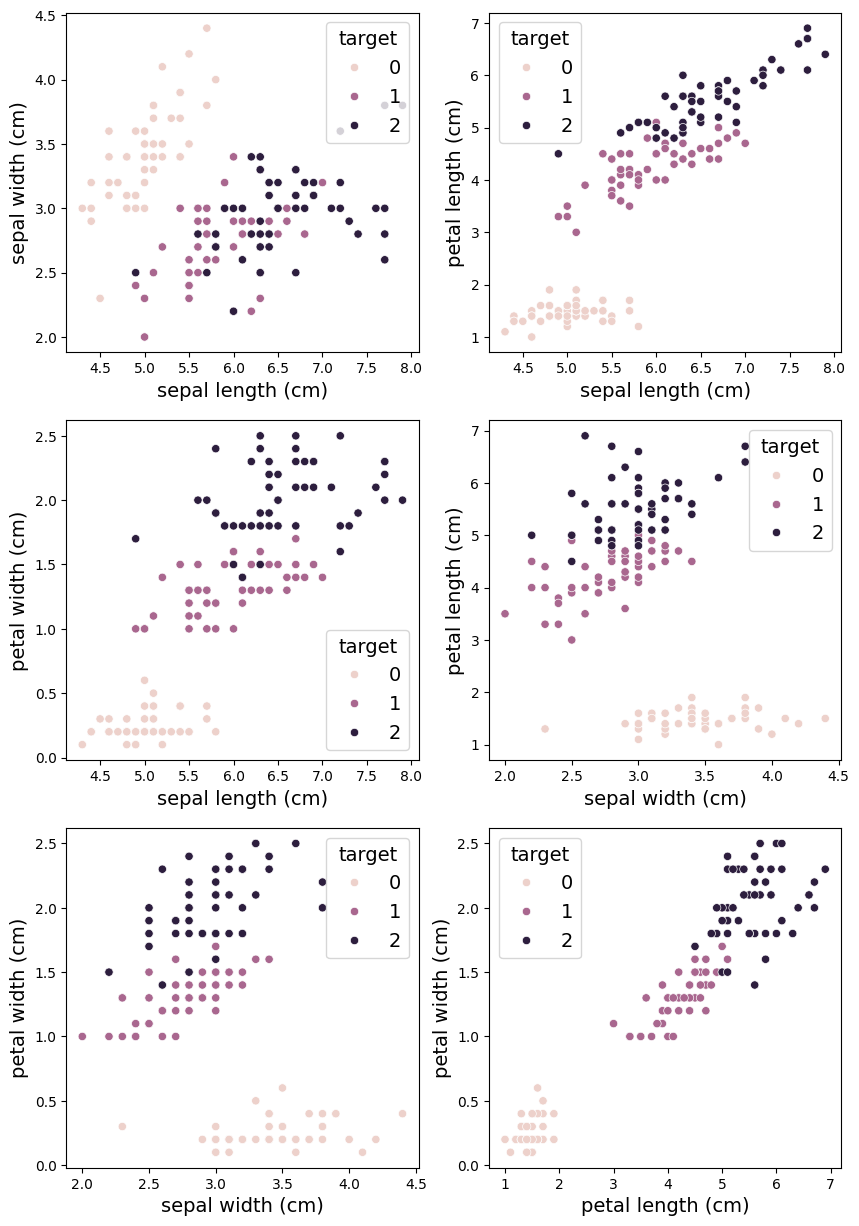

In [ ]:
fig, axis = plt.subplots(3, 2, figsize=(10, 15))
for combination, ax in zip(itertools.combinations(iris_df.columns[:-1], 2), axis.flatten()):
    sns.scatterplot(iris_df, x=combination[0], y=combination[1], hue=iris_df["target"], ax=ax)

In [ ]:
class _Node:
    """Internal tree node (either decision or leaf)."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature   = feature     # index of split feature
        self.threshold = threshold   # split threshold
        self.left      = left        # _Node
        self.right     = right       # _Node
        self.value     = value       # class label for leaf

    def is_leaf(self):
        return self.value is not None


class DecisionTreeClassifierScratch:
    """Minimal CART-like decision tree (Gini, binary splits)."""
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.root              = None                 # set by fit()

    # -------- public API ----------------------------------------------------
    def fit(self, X, y):
        """Build the tree."""
        X, y = np.asarray(X), np.asarray(y)
        self.n_classes_  = len(np.unique(y))
        self.n_features_ = X.shape[1] # (num_samples, num_features)
        self.root = self._grow_tree(X, y, depth=0)
        return self

    def predict(self, X):
        """Vectorised prediction for a 2-D array."""
        X = np.asarray(X)
        return np.array([self._predict_one(row, self.root) for row in X])

    # -------- internals ------------------------------------------------------
    def _gini(self, y):
        m = len(y)
        return 1.0 - sum((np.sum(y == c) / m) ** 2 for c in range(self.n_classes_))

    def _best_split(self, X, y):
        """Return best (feature idx, threshold) or (None, None) if no split."""
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        best_gain, best_idx, best_thr = 0.0, None, None
        parent_imp = self._gini(y)

        for idx in range(n):
            # sort feature to evaluate split positions in O(m log m)
            sorted_idx = X[:, idx].argsort()
            thresholds = X[sorted_idx, idx]
            classes    = y[sorted_idx]

            left_counts  = [0] * self.n_classes_ # feature : [1, 2, 3, 4, 5] label: [1, 1, 0, 0, 0]
            right_counts = Counter(classes) # left count = [1, 2], right count [2, 0]

            for i in range(1, m):  # i samples in left partition
                c = classes[i-1]
                left_counts[c]  += 1
                right_counts[c] -= 1

                if thresholds[i] == thresholds[i-1]:  # identical → skip
                    continue

                left_imp  = 1.0 - sum((left_counts[k]  / i)       ** 2 for k in range(self.n_classes_))
                right_imp = 1.0 - sum((right_counts[k] / (m - i)) ** 2 for k in range(self.n_classes_))
                gain = parent_imp - (i / m) * left_imp - ((m - i) / m) * right_imp

                if gain > best_gain:
                    best_gain = gain
                    best_idx  = idx
                    best_thr  = (thresholds[i] + thresholds[i-1]) / 2.0

        return best_idx, best_thr

    def _grow_tree(self, X, y, depth):
        """Recursively build the tree starting at (X, y)."""
        num_per_class = [np.sum(y == c) for c in range(self.n_classes_)]
        pred_class = int(np.argmax(num_per_class)) # [2, 3, 5] --> [20, 30, 50]

        # stop criteria
        if (self.max_depth is not None and depth >= self.max_depth) or len(set(y)) == 1:
            return _Node(value=pred_class)

        feat_idx, thr = self._best_split(X, y)
        if feat_idx is None:
            return _Node(value=pred_class)

        left_mask = X[:, feat_idx] < thr
        right_mask = ~left_mask

        return _Node(
            feature   = feat_idx,
            threshold = thr,
            left      = self._grow_tree(X[left_mask],  y[left_mask],  depth + 1),
            right     = self._grow_tree(X[right_mask], y[right_mask], depth + 1)
        )

    def _predict_one(self, x, node):
        """Traverse the tree for a single sample."""
        while not node.is_leaf():
            node = node.left if x[node.feature] < node.threshold else node.right
        return node.value

In [ ]:
iris_train, iris_test = train_test_split(iris_df, test_size=0.2)

In [ ]:
model = DecisionTreeClassifierScratch(max_depth=2)
model.fit(iris_train.iloc[:, :-1], iris_train.iloc[:, -1])

In [ ]:
train_predictions = model.predict(iris_train.iloc[:, :-1])
print(f"Accuracy of the model is equal to: {accuracy_score(iris_train.iloc[:, -1], train_predictions)}")
print(f"Recall of the model is equal to: {recall_score(iris_train.iloc[:, -1], train_predictions, average='micro')}") # 4 / 5, 3 / 5 --> (4 + 3) / (5 + 5)
print(f"Recall of the model is equal to: {recall_score(iris_train.iloc[:, -1], train_predictions, average='macro')}") # (4 / 5 + 3 / 5) / 2
print(f"F1 of the model is equal to: {f1_score(iris_train.iloc[:, -1], train_predictions, average='micro')}")
print(f"F1 of the model is equal to: {f1_score(iris_train.iloc[:, -1], train_predictions, average='macro')}")

Accuracy of the model is equal to: 0.9583333333333334
Recall of the model is equal to: 0.9583333333333334
Recall of the model is equal to: 0.9585365853658536
F1 of the model is equal to: 0.9583333333333334
F1 of the model is equal to: 0.9587471352177235


<Axes: >

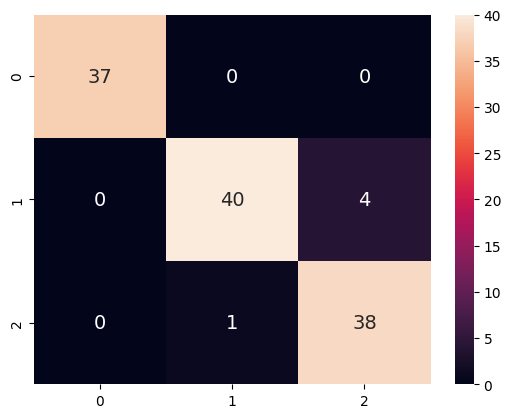

In [ ]:
conf_mat = confusion_matrix(iris_train.iloc[:, -1], train_predictions)
sns.heatmap(conf_mat, annot=True)

In [ ]:
test_predictions = model.predict(iris_test.iloc[:, :-1])
print(f"Accuracy of the model is equal to: {accuracy_score(iris_test.iloc[:, -1], test_predictions)}")
print(f"Recall of the model is equal to: {recall_score(iris_test.iloc[:, -1], test_predictions, average='micro')}")
print(f"Recall of the model is equal to: {recall_score(iris_test.iloc[:, -1], test_predictions, average='macro')}")
print(f"Recall of the model is equal to: {f1_score(iris_test.iloc[:, -1], test_predictions, average='micro')}")
print(f"Recall of the model is equal to: {f1_score(iris_test.iloc[:, -1], test_predictions, average='macro')}")

Accuracy of the model is equal to: 0.9666666666666667
Recall of the model is equal to: 0.9666666666666667
Recall of the model is equal to: 0.9666666666666667
Recall of the model is equal to: 0.9666666666666667
Recall of the model is equal to: 0.9649122807017543


<Axes: >

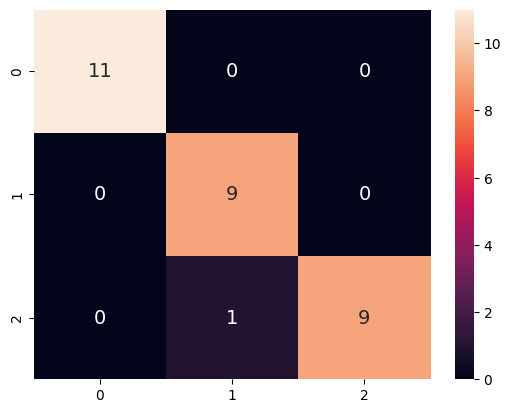

In [ ]:
conf_mat = confusion_matrix(iris_test.iloc[:, -1], test_predictions)
sns.heatmap(conf_mat, annot=True)

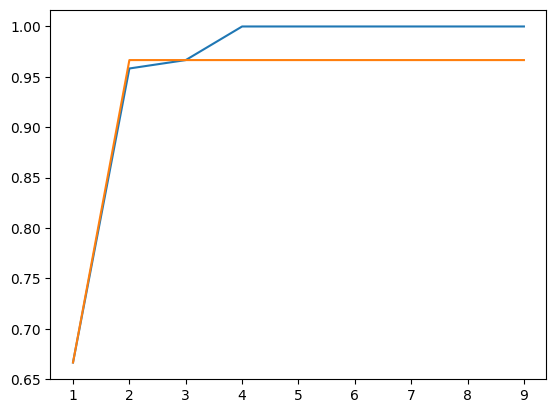

In [ ]:
## Overfit
train_accuracies = []
test_accuracies = []
for depth in range(1, 10):
    model = DecisionTreeClassifierScratch(max_depth=depth)
    model.fit(iris_train.iloc[:, :-1], iris_train.iloc[:, -1])
    train_predictions = model.predict(iris_train.iloc[:, :-1])
    test_predictions = model.predict(iris_test.iloc[:, :-1])
    train_accuracies.append(accuracy_score(iris_train.iloc[:, -1], train_predictions))
    test_accuracies.append(accuracy_score(iris_test.iloc[:, -1], test_predictions))

plt.plot(list(range(1, 10)), train_accuracies)
plt.plot(list(range(1, 10)), test_accuracies)

In [ ]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),  # path differs in the book
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

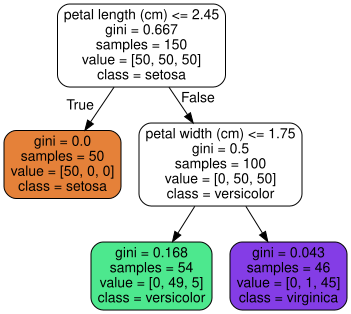

In [ ]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

In [ ]:
a = np.linspace(0, 1, 5)
b = np.linspace(0, 1, 5)
np.meshgrid(a, b)

(array([[0.  , 0.25, 0.5 , 0.75, 1.  ],
        [0.  , 0.25, 0.5 , 0.75, 1.  ],
        [0.  , 0.25, 0.5 , 0.75, 1.  ],
        [0.  , 0.25, 0.5 , 0.75, 1.  ],
        [0.  , 0.25, 0.5 , 0.75, 1.  ]]),
 array([[0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.25, 0.25, 0.25, 0.25, 0.25],
        [0.5 , 0.5 , 0.5 , 0.5 , 0.5 ],
        [0.75, 0.75, 0.75, 0.75, 0.75],
        [1.  , 1.  , 1.  , 1.  , 1.  ]]))

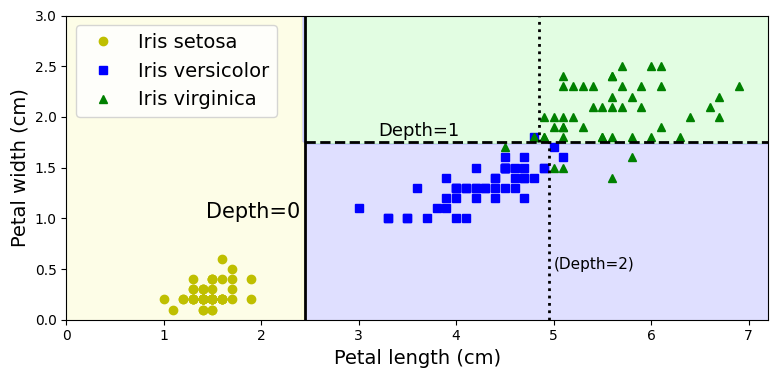

In [ ]:
# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies and saves Figure 6–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

In [ ]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

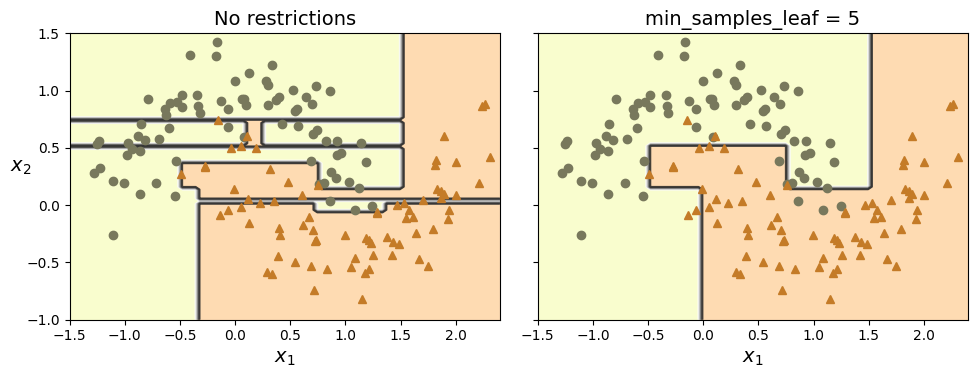

In [ ]:
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

In [ ]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [ ]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

In [ ]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # a single random input feature
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

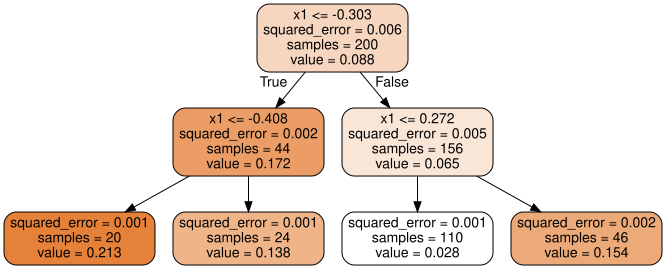

In [ ]:
# extra code – we've already seen how to use export_graphviz()
export_graphviz(
    tree_reg,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

In [ ]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
tree_reg.tree_.threshold

array([-0.30265072, -0.40830374, -2.        , -2.        ,  0.27175756,
       -2.        , -2.        ])

In [ ]:
tree_reg2.tree_.threshold

array([-0.30265072, -0.40830374, -0.45416115, -2.        , -2.        ,
       -0.37022041, -2.        , -2.        ,  0.27175756, -0.21270403,
       -2.        , -2.        ,  0.40399227, -2.        , -2.        ])

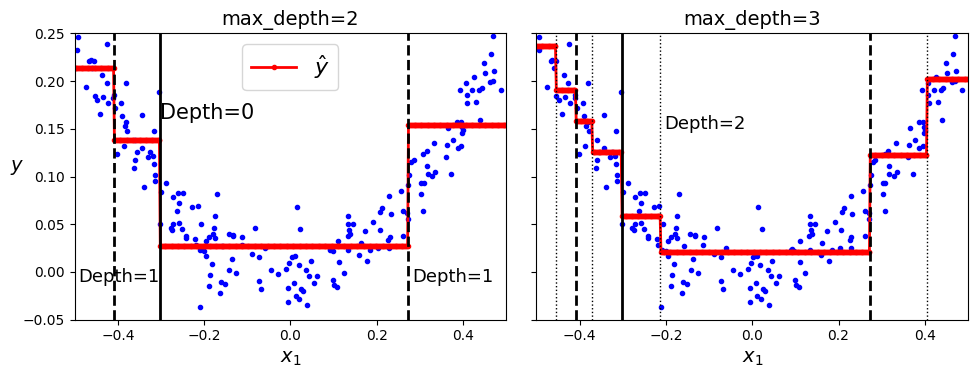

In [ ]:
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

save_fig("tree_regression_plot")
plt.show()

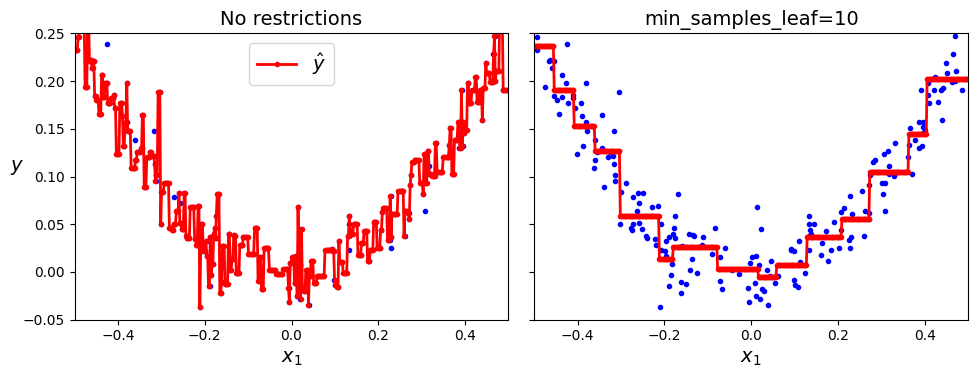

In [ ]:
# extra code – this cell generates and saves Figure 6–6

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

save_fig("tree_regression_regularization_plot")
plt.show()

## Exercies:

1. Show that decision tree is sensitive to rotations.

Steps:

- Generate random data in a square
- Give them labels based on a vertical axis
- fit a decision tree
- rotate the points by 45 degrees
- again fit a decision tree.
- see the differences.

2. Real overfit in Decision Trees : )

Step:


- Use digits dataset in sklearn
- Apply tsne algorithm to reduce dimension and visualize
- Apply decision tree with different depthes
- See the overfitting phenomena

In [ ]:
from sklearn.datasets import load_digits

from sklearn.manifold import TSNE

In [ ]:
dataset = load_digits()
X = dataset["data"]
y = dataset["target"]

In [ ]:
model = TSNE(n_components=2)
X_reduced = model.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y)

<Axes: >

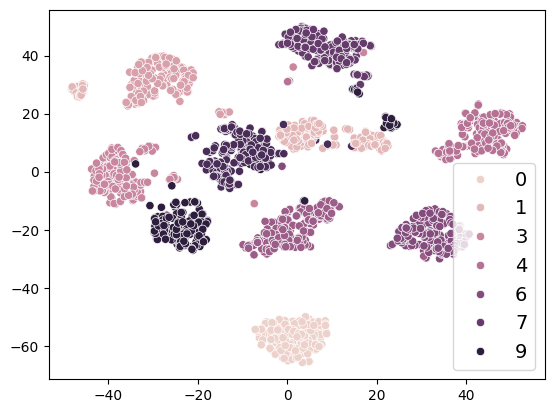

In [ ]:
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=y)

In [ ]:
train_scores = []
validation_scores = []

for depth in range(1, 30):
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    validation_scores.append(model.score(X_test, y_test))

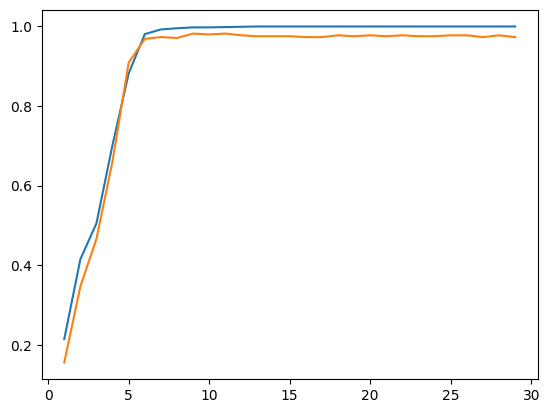

In [ ]:
plt.plot(list(range(1, 30)), train_scores)
plt.plot(list(range(1, 30)), validation_scores)

exercise 2

In [ ]:
# [-1, 1], [-1, 1]
# x random, y random --> uniform
# (100, 2) --> 100, 2 fetures
# generate
X = np.random.uniform(-1, 1, size=(100, 2))


In [ ]:
# y = مولفه اول کمتر از صفر کلاس صفر آن هایی که بیشتر میشن کلاس ۱
y = (X[:, 0] > 0).astype(int)
y

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

<Axes: >

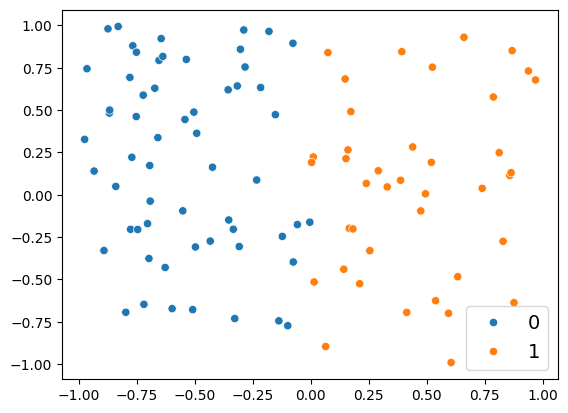

In [ ]:
# plot X, y

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [ ]:
## fit decsion tree to see the results

model = DecisionTreeClassifier(max_depth=5)
model.fit(X, y)

DecisionTreeClassifier(max_depth=5)

In [ ]:
rotation_matrix = np.array([[np.cos(np.pi / 4), np.sin(np.pi / 4)], [-np.sin(np.pi / 4), np.cos(np.pi / 4)]])
rotation_matrix

array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]])

<Axes: >

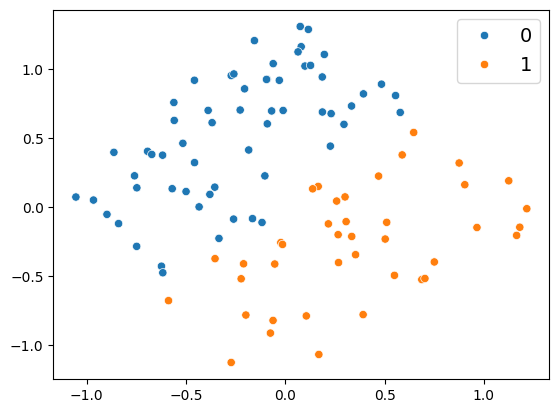

In [ ]:
# (n, m), (m, k) (2, 2) (100, 2)
rotated_X = (rotation_matrix @ X.T).T
sns.scatterplot(x=rotated_X[:, 0], y=rotated_X[:, 1], hue=y)

In [ ]:
model = DecisionTreeClassifier(max_depth=50)
model.fit(rotated_X, y)

DecisionTreeClassifier(max_depth=50)

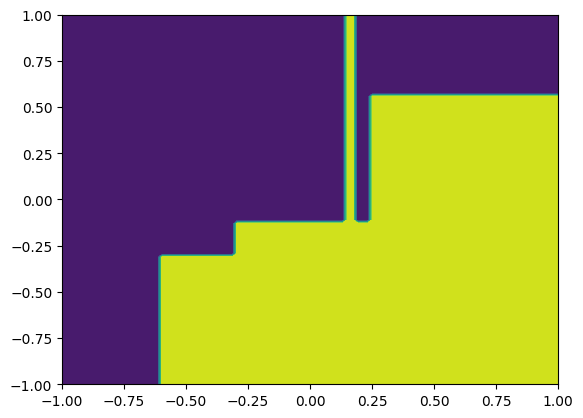

In [ ]:
width, height = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
data = np.concatenate([width.reshape(-1, 1), height.reshape(-1, 1)], axis=1)
decisions = model.predict(data).reshape(width.shape)

plt.contourf(width, height, decisions)

In [ ]:
width.shape

(100, 100)